nltools.data.brain_data.Brain_Data(data=(50, 238955), Y=(0, 0), X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz)

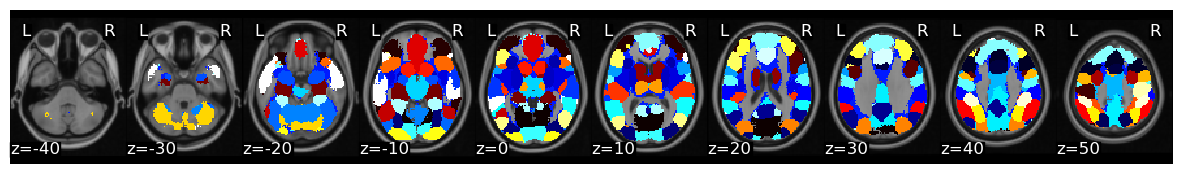

In [1]:
import os
from nltools.mask import expand_mask, roi_to_brain
from nltools.data import Brain_Data, Adjacency

from nltools.prefs import MNI_Template
from nilearn.plotting import plot_glass_brain
import warnings
warnings.filterwarnings('ignore')

MNI_Template['resolution'] = '2mm' ## mask specify

import os
from pathlib import Path

current_directory = '/Storage/Data/nes_menghan/code_menghan/NeuroExperience/'
svg_file = 'svg_files' ## svg plots

base_dir = '/Storage/Data/nes/'
mask = Brain_Data(os.path.join(base_dir, 'code_menghan', 'Mask', 'k50_2mm.nii.gz'))
mask.plot()
#expand this mask into 50 separate regions
mask_x = expand_mask(mask) 
mask_x

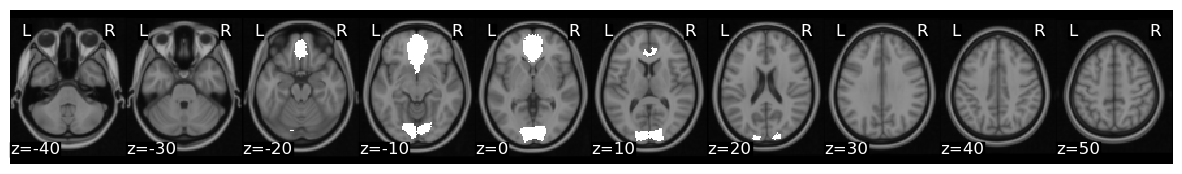

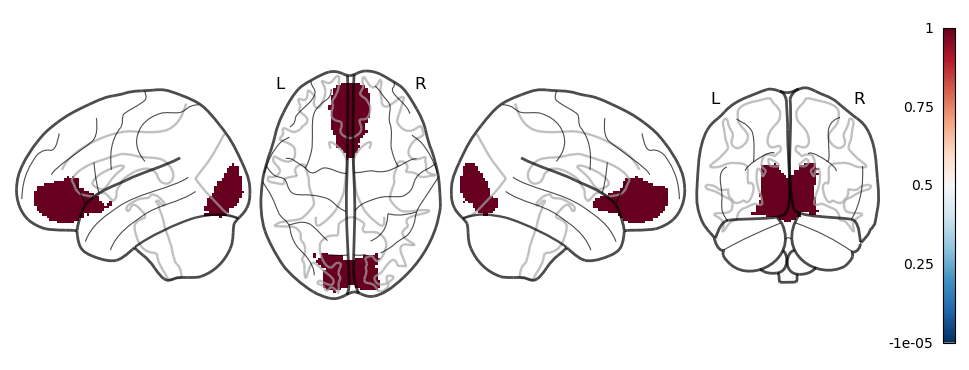

In [2]:
mask_cbd = mask_x[4] + mask_x[32]
mask_cbd.plot()

# mask_cbd = mask_cbd.to_nifti()
plot_glass_brain(mask_cbd.to_nifti(), display_mode='lzry',colorbar=True,cmap='RdBu_r',plot_abs=False)


### Participants with 5 scan sessions and proper head coils

In [3]:
data_dir = '/Storage/Data/nes_menghan/preprocessed/final/'
subj_sids_list = os.listdir(data_dir)
subj_sids_iteration = []
for subj in subj_sids_list:
    subj_path = os.path.join(data_dir, subj)
    subj_path_sess = os.listdir(subj_path)
    if len(subj_path_sess) == 5:
        subj_sids_iteration.append(subj)
    
    
subj_sids_iteration.remove('sub-sid001215') ###the Timepoints of this subject's third session were fewer than others
subj_sids_iteration.remove('sub-sid001473') ### the fifth

subj_sids_iteration.remove('sub-sid000860') 
subj_sids_iteration.remove('sub-sid001201')  ### head coil issue: HEP
print(len(subj_sids_iteration))
subj_sids_iteration

20


['sub-sid001377',
 'sub-sid001277',
 'sub-sid001280',
 'sub-sid001367',
 'sub-sid000846',
 'sub-sid001274',
 'sub-sid001397',
 'sub-sid001358',
 'sub-sid001276',
 'sub-sid000381',
 'sub-sid001286',
 'sub-sid001282',
 'sub-sid000854',
 'sub-sid001555',
 'sub-sid001291',
 'sub-sid000780',
 'sub-sid001302',
 'sub-sid001296',
 'sub-sid001278',
 'sub-sid000861']

### Onset Time and Movie name 

In [4]:
import pandas as pd

onset_movie = os.path.join('/Storage/Data/nes_menghan/', 'code_menghan', 'NeuroExperience','onset_movie.txt')

onset_movie = pd.read_csv(onset_movie,sep='\t').set_index('Movie name')
onset_movie


,Scanning run,Starting TR,Ending TR,Trim_Starting TR,Trim_Ending TR,Entire Onset,Entire Ending
Movie name,,,,,,,
Nature,run1,8,52,3,47,3,47
Asian cake,run1,62,185,57,180,57,180
Ribbon climbing,run1,194,335,189,330,189,330
Kiss me,run1,344,485,339,480,339,480
Syrian,run1,495,584,490,579,490,579
Salad,run2,8,138,3,133,591,721
Angelina Hale,run2,147,277,142,272,730,860
Soccer,run2,285,410,280,405,868,993
Dancing lady,run2,419,529,414,524,1002,1112


In [5]:
movie_length = pd.DataFrame(onset_movie['Ending TR']-onset_movie['Starting TR'])
movie_length_seconds = movie_length*2



In [7]:
print(movie_length_seconds.mean())
print(movie_length_seconds.std())

0    228.166667
dtype: float64
0    69.417243
dtype: float64


### Between-subjects ISC across five times

In [5]:
def calculate_between_ISC(subj_sids_iteration,session_num,roi_num):
    data_all_subj = pd.DataFrame([])
    

    onset_movie = os.path.join('/Storage/Data/nes_menghan/', 'code_menghan', 'NeuroExperience','onset_movie.txt')
    onset_movie = pd.read_csv(onset_movie,sep='\t').set_index('Movie name')
    
    
    for sub_name in subj_sids_iteration:
        isc_data = glob.glob(os.path.join('/Storage/Data/nes_menghan/denoised/Denoised_ROI',f"{sub_name}_ses{session_num}_Denoised_ROI_{roi_num}.csv"))
        isc_data = pd.read_csv(isc_data[0])
        if len(data_all_subj) == 0:
            data_all_subj = isc_data
        else:
            data_all_subj = np.concatenate((data_all_subj,isc_data),axis = 1)
            
    video_corr = []        
    for video_label in range(24):
        video_sess = []
        video_onset = onset_movie['Entire Onset'][video_label]-1
        video_end = onset_movie['Entire Ending'][video_label]-1
        video_sess = data_all_subj[video_onset:video_end+1,:]

        video_data = pd.DataFrame(video_sess)
#         video_data = video_data.T
        video_data_corr = video_data.corr()
        video_data_corr_np = video_data_corr.to_numpy()
        video_data_corr_trail = video_data_corr_np[np.triu_indices(len(subj_sids_iteration), 1)]

#         video_corr_data.append([np.mean(video_data_corr_trail)])
        video_corr.append(np.mean(video_data_corr_trail))
        
    sub_movie_corr = pd.DataFrame()
    sub_movie_corr['between-subject similarity'] = pd.DataFrame(video_corr)
    sub_movie_corr['movie_name'] = onset_movie.index
    sub_movie_corr = sub_movie_corr.set_index('movie_name')

    return sub_movie_corr

#### V1 

In [7]:
import pandas as pd
import glob
import time
from tqdm.notebook import tqdm
import numpy as np
import xarray as xr
from joblib import Parallel, delayed

roi_num = 4
ses_all = ['1','2','3','4','5']
ISC_all_corr_V1 = pd.DataFrame([])

for session_time in tqdm(ses_all):
    ISC_between = calculate_between_ISC(subj_sids_iteration,session_time,roi_num)
    ISC_between = np.arctanh(ISC_between)
    ISC_between['session time'] = session_time
    
    ISC_all_corr_V1 = pd.concat([ISC_all_corr_V1,ISC_between])

  0%|          | 0/5 [00:00<?, ?it/s]

In [8]:
ISC_all_corr_V1.pivot(columns='session time',values = 'between-subject similarity')

session time,1,2,3,4,5
movie_name,,,,,
1 second,0.476647,0.486032,0.264248,0.123783,0.242185
Angelina Hale,0.452180,0.262164,0.172998,0.102827,0.131925
Asian cake,0.479828,0.440768,0.285215,0.221836,0.204495
Burgers,0.291860,0.230434,0.165250,0.115795,0.153204
Cookies,0.372531,0.276483,0.201390,0.055500,0.085497
Dancing lady,0.516727,0.386796,0.239567,0.163899,0.180877
Family,0.346513,0.299870,0.159474,0.142863,0.106863
Farewell,0.362882,0.288043,0.131372,0.071330,0.122534
Ingrid Silva,0.384967,0.275223,0.168684,0.151116,0.120485


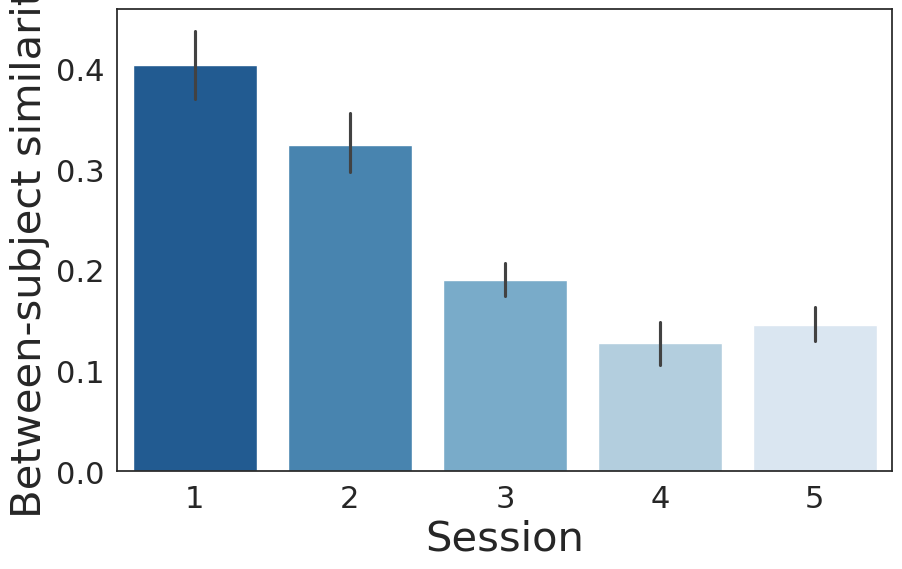

In [65]:
import seaborn as sns
import pandas as pd
import matplotlib # if abbreviating this, use "as mpl"
import matplotlib.pyplot as plt

sns.set(font_scale=2)
sns.set_style('white')
plt.figure(figsize=(10,6))
sns.barplot(data =ISC_all_corr_V1, x = 'session time', y = 'between-subject similarity',palette = "Blues_r")
plt.xlabel('Session',fontsize=30);
plt.ylabel('Between-subject similarity',fontsize=30);


plt.savefig(os.path.join(current_directory,svg_file,"V1_session_between.svg"), format="svg")

## Vmpfc

In [9]:
roi_num = 32
ses_all = ['1','2','3','4','5']
ISC_all_corr_Vmpfc = pd.DataFrame([])

for session_time in tqdm(ses_all):
    ISC_between = calculate_between_ISC(subj_sids_iteration,session_time,roi_num)
    ISC_between = np.arctanh(ISC_between)
    ISC_between['session time'] = session_time
    
    ISC_all_corr_Vmpfc = pd.concat([ISC_all_corr_Vmpfc,ISC_between])

  0%|          | 0/5 [00:00<?, ?it/s]

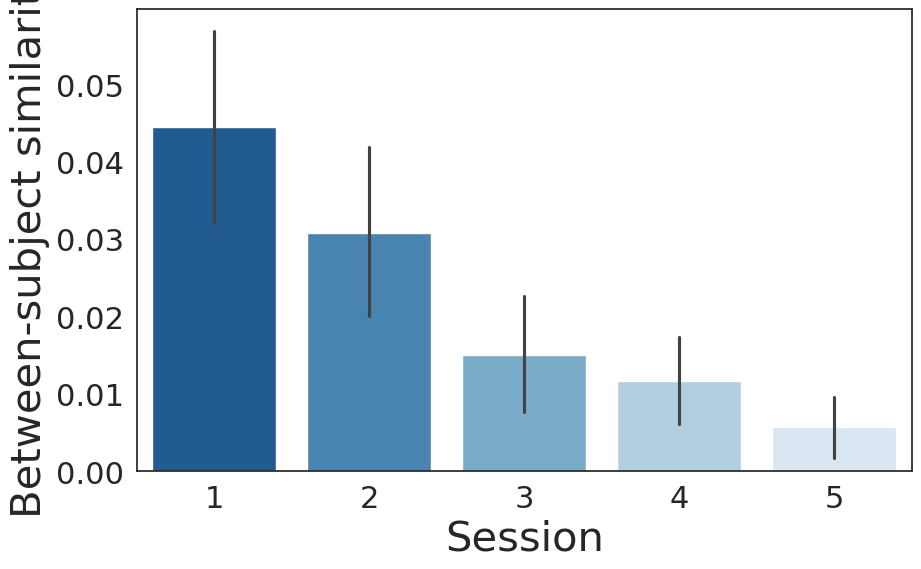

In [69]:


sns.set(font_scale=2)
sns.set_style('white')
plt.figure(figsize=(10,6))
sns.barplot(data =ISC_all_corr_Vmpfc, x = 'session time', y = 'between-subject similarity',palette = "Blues_r")
plt.xlabel('Session',fontsize=30);
plt.ylabel('Between-subject similarity',fontsize=30);


plt.savefig(os.path.join(current_directory,svg_file,"vmPFC_session_between.svg"), format="svg")


## Within-subject corr

In [6]:
def calculate_within_ISC(subj_sids_iteration,session_num,roi_num):

    onset_movie = os.path.join('/Storage/Data/nes_menghan/', 'code_menghan', 'NeuroExperience','onset_movie.txt')
    onset_movie = pd.read_csv(onset_movie,sep='\t').set_index('Movie name')
    
    suball_movie_corr = pd.DataFrame()
    
    
    for sub_name in subj_sids_iteration:
        data_subj_session = pd.DataFrame([])
        isc_data = glob.glob(os.path.join('/Storage/Data/nes_menghan/denoised/Denoised_ROI',f"{sub_name}_ses*_Denoised_ROI_{roi_num}.csv"))
        isc_data.sort()
        for i in range(session_num):
            isc_data_session = pd.read_csv(isc_data[i])
            if len(data_subj_session) == 0:
                data_subj_session = isc_data_session
            else:
                data_subj_session = np.concatenate((data_subj_session,isc_data_session),axis = 1)
        
        video_corr = []
#         video_corr_data = []
        for video_label in range(24):
            video_sess = []
            video_onset = onset_movie['Entire Onset'][video_label]-1
            video_end = onset_movie['Entire Ending'][video_label]-1
            video_sess = data_subj_session[video_onset:video_end+1,:] 

            video_data = pd.DataFrame(video_sess)
#             video_data = video_data.T
            video_data_corr = video_data.corr()
            video_data_corr_np = video_data_corr.to_numpy()
            video_data_corr_trail = video_data_corr_np[np.triu_indices(session_num, 1)]

#             video_corr_data.append([np.mean(video_data_corr_trail)])
            video_corr.append(np.mean(video_data_corr_trail))

        sub_movie_corr = pd.DataFrame()
        sub_movie_corr['video_corr'] = pd.DataFrame(video_corr)
        sub_movie_corr['subj'] = sub_name
        sub_movie_corr['movie_name'] = onset_movie.index

        suball_movie_corr = pd.concat([suball_movie_corr,sub_movie_corr])
        
    suball_movie_corr_mean_V1_within = suball_movie_corr.groupby(['movie_name'])['video_corr'].mean()
    
    return suball_movie_corr_mean_V1_within


In [11]:
V1_within = calculate_within_ISC(subj_sids_iteration,5,4)
vmPFC_within = calculate_within_ISC(subj_sids_iteration,5,32)

### Within between comparison 

In [12]:
ISC_all_corr_V1_mean = ISC_all_corr_V1.pivot(columns='session time',values = 'between-subject similarity').mean(axis = 1)
ISC_all_corr_V1_mean

movie_name
1 second           0.318579
Angelina Hale      0.224419
Asian cake         0.326428
Burgers            0.191309
Cookies            0.198280
Dancing lady       0.297573
Family             0.211117
Farewell           0.195232
Ingrid Silva       0.220095
Kiss me            0.171418
Lapse              0.218359
Lasagna            0.225923
Nature             0.270901
Newsroom           0.274290
Porn               0.215004
Ramen              0.204056
Ribbon climbing    0.175166
Russian            0.302468
Salad              0.239617
Skiing             0.247067
Sky surfing        0.350639
Soccer             0.208856
Syrian             0.235793
The present        0.200807
dtype: float64

In [13]:
sub_movie_corr_V1_between = ISC_all_corr_V1[ISC_all_corr_V1['session time'] == '1']['between-subject similarity']

In [14]:
ISC_combined_V1_2 = pd.concat([V1_within,sub_movie_corr_V1_between,ISC_all_corr_V1_mean],axis = 1,join='inner',keys = ['V1 within-subject ISC','V1 between-subject ISC','mean between-subject ISC'])
ISC_combined_V1_2

,V1 within-subject ISC,V1 between-subject ISC,mean between-subject ISC
movie_name,,,
1 second,0.359373,0.476647,0.318579
Angelina Hale,0.263155,0.452180,0.224419
Asian cake,0.366754,0.479828,0.326428
Burgers,0.242486,0.291860,0.191309
Cookies,0.228249,0.372531,0.198280
Dancing lady,0.351490,0.516727,0.297573
Family,0.265678,0.346513,0.211117
Farewell,0.212962,0.362882,0.195232
Ingrid Silva,0.250972,0.384967,0.220095


In [19]:
ISC_combined_V1_2.columns = ['V1 within-subject similarity','V1 first session between-subject similarity','V1 mean between-subject similarity']


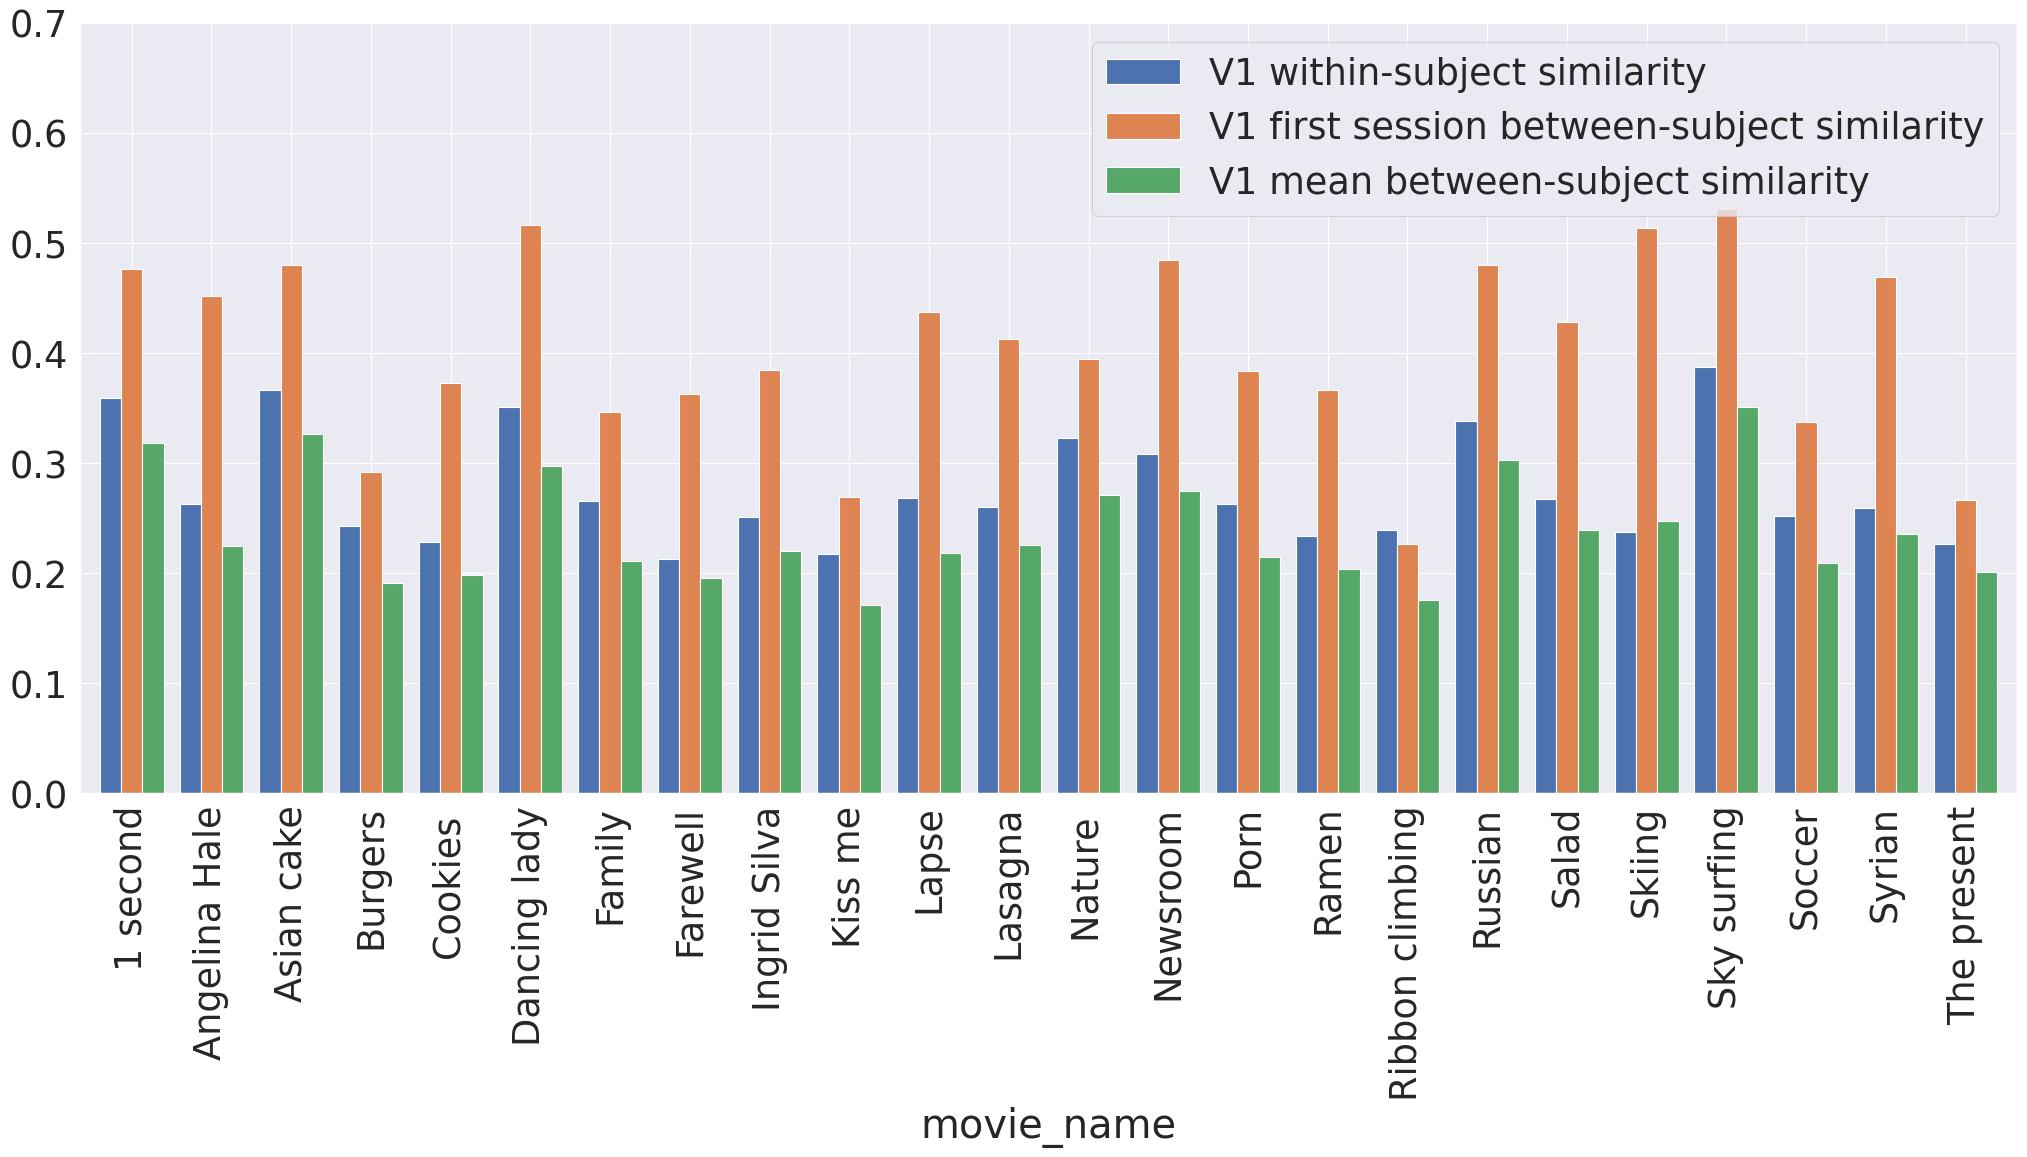

In [207]:
with sns.plotting_context(context='paper', font_scale=3): 
    ISC_combined_V1_2.plot.bar(figsize=(25,10),ylim = [0,0.7],width=0.8,color = colors)
    plt.legend(loc = 'upper right')
    plt.savefig(os.path.join(current_directory,svg_file,"between_within_comparison_V1_videos.svg"), format="svg")

(array([0, 1, 2]),
 [Text(0, 0, 'V1 within-subject similarity'),
  Text(1, 0, 'V1 first session between-subject similarity'),
  Text(2, 0, 'V1 mean between-subject similarity')])

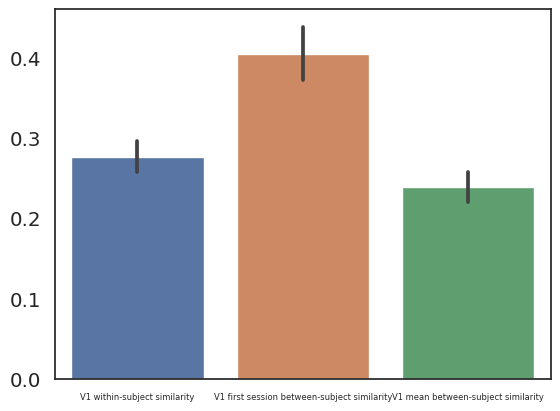

In [42]:
sns.barplot(data = ISC_combined_V1_2)
plt.xticks(fontsize = 6)

In [15]:
sub_movie_corr_Vmpfc_between = ISC_all_corr_Vmpfc[ISC_all_corr_Vmpfc['session time'] == '1']['between-subject similarity']

In [16]:
ISC_all_corr_Vmpfc_mean = ISC_all_corr_Vmpfc.pivot(columns='session time',values = 'between-subject similarity').mean(axis = 1)
ISC_all_corr_Vmpfc_mean

movie_name
1 second           0.004305
Angelina Hale      0.022770
Asian cake         0.017944
Burgers            0.030997
Cookies            0.016313
Dancing lady       0.038550
Family             0.022015
Farewell           0.015939
Ingrid Silva       0.030046
Kiss me            0.009605
Lapse              0.003698
Lasagna            0.039002
Nature             0.005078
Newsroom           0.042683
Porn               0.030436
Ramen              0.050063
Ribbon climbing    0.008530
Russian            0.028093
Salad              0.023085
Skiing             0.014917
Sky surfing        0.003097
Soccer             0.009679
Syrian             0.015979
The present        0.034011
dtype: float64

In [17]:
ISC_combined_Vmpfc_2 = pd.concat([vmPFC_within,sub_movie_corr_Vmpfc_between,ISC_all_corr_Vmpfc_mean],axis = 1,join='inner',keys = ['Vmpfc within-subject ISC','Vmpfc between-subject ISC','mean between-subject ISC'])
ISC_combined_Vmpfc_2

,Vmpfc within-subject ISC,Vmpfc between-subject ISC,mean between-subject ISC
movie_name,,,
1 second,0.054184,0.004460,0.004305
Angelina Hale,0.049900,0.033053,0.022770
Asian cake,0.031324,0.031468,0.017944
Burgers,0.048540,0.068857,0.030997
Cookies,0.034466,0.048709,0.016313
Dancing lady,0.047361,0.068738,0.038550
Family,0.075800,0.020912,0.022015
Farewell,0.028742,0.042699,0.015939
Ingrid Silva,0.052347,0.064001,0.030046


In [18]:
ISC_combined_Vmpfc_2.columns = ['vmPFC within-subject similarity','vmPFC first session between-subject similarity','vmPFC mean between-subject similarity']

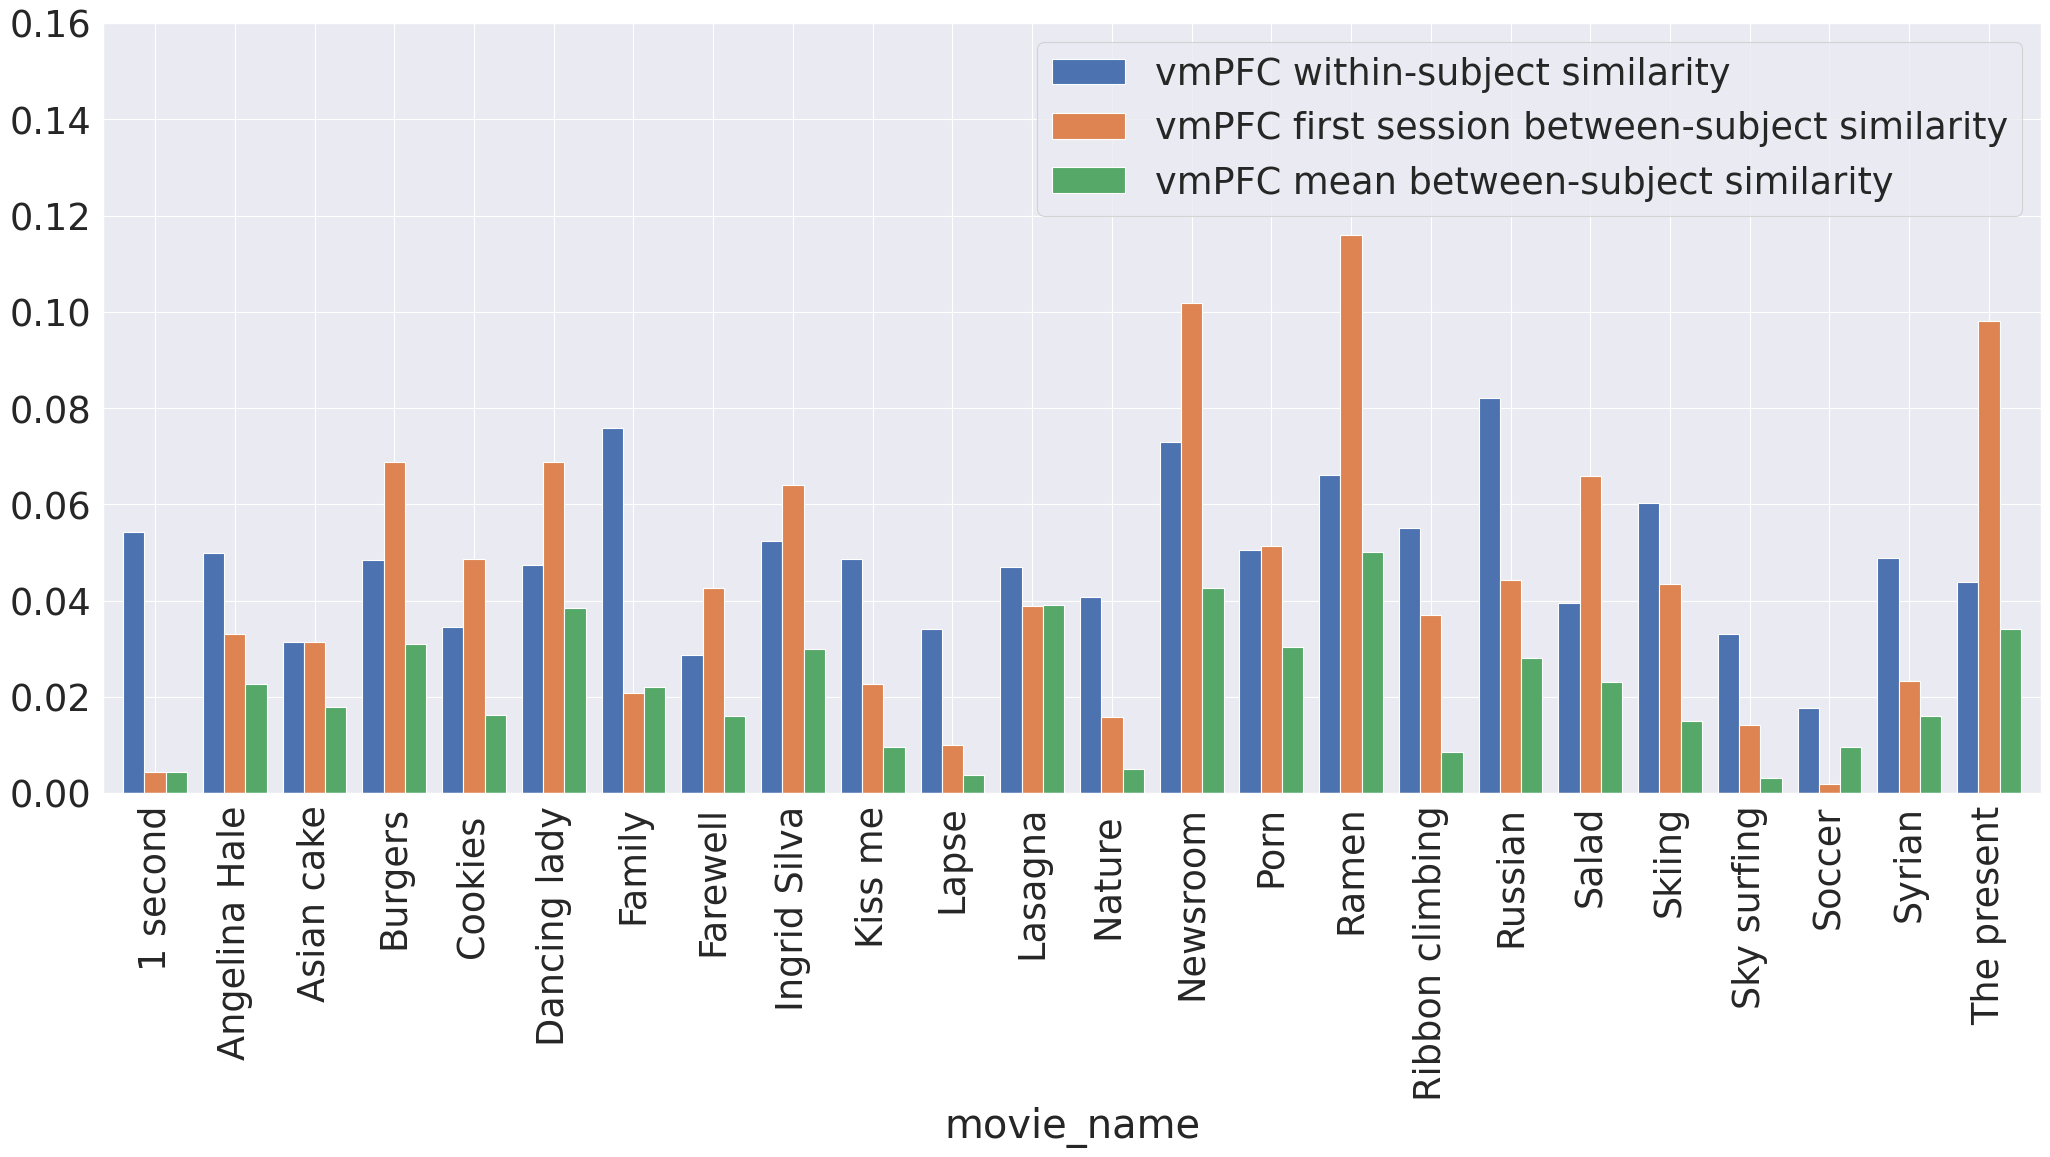

In [203]:
colors = sns.color_palette("deep")

with sns.plotting_context(context='paper', font_scale=3): 
    ISC_combined_Vmpfc_2.plot.bar(figsize=(25,10),ylim = [0,0.16],width=0.8,color = colors)
    plt.legend(loc = 'upper right')
    plt.savefig(os.path.join(current_directory,svg_file,"between_within_comparison_vmPFC_videos.svg"), format="svg")

(array([0, 1, 2]),
 [Text(0, 0, 'vmPFC within-subject similarity'),
  Text(1, 0, 'vmPFC first session between-subject similarity'),
  Text(2, 0, 'vmPFC mean between-subject similarity')])

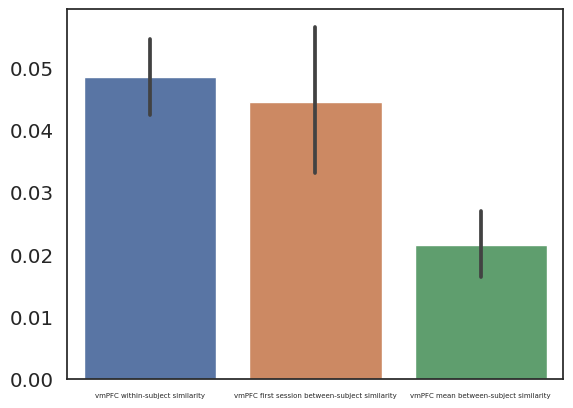

In [55]:
sns.barplot(data = ISC_combined_Vmpfc_2)
plt.xticks(fontsize = 5)

In [20]:
ISC_combined_V1_2.columns = ['within-subject similarity','first session between-subject similarity','mean between-subject similarity']
ISC_combined_V1_all = ISC_combined_V1_2.stack().reset_index()
ISC_combined_V1_all['brain'] = 'V1'

In [21]:
ISC_combined_Vmpfc_2.columns = ['within-subject similarity','first session between-subject similarity','mean between-subject similarity']
ISC_combined_Vmpfc_all = ISC_combined_Vmpfc_2.stack().reset_index()
ISC_combined_Vmpfc_all['brain'] = 'vmPFC'

In [22]:
V1_vmpfc_ISC_Combined = pd.concat([ISC_combined_V1_all,ISC_combined_Vmpfc_all],axis = 0)
V1_vmpfc_ISC_Combined.columns = ['video namne','similarity type','correlations','ROIs']
V1_vmpfc_ISC_Combined

,video namne,similarity type,correlations,ROIs
0,1 second,within-subject similarity,0.359373,V1
1,1 second,first session between-subject similarity,0.476647,V1
2,1 second,mean between-subject similarity,0.318579,V1
3,Angelina Hale,within-subject similarity,0.263155,V1
4,Angelina Hale,first session between-subject similarity,0.452180,V1
...,...,...,...,...
67,Syrian,first session between-subject similarity,0.023354,vmPFC
68,Syrian,mean between-subject similarity,0.015979,vmPFC
69,The present,within-subject similarity,0.043960,vmPFC
70,The present,first session between-subject similarity,0.098057,vmPFC


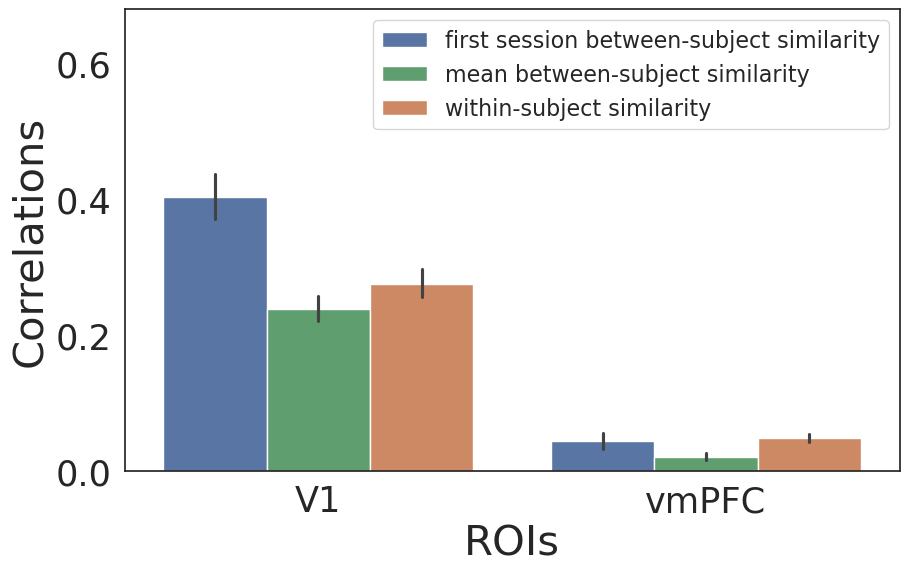

In [89]:
sns.set(font_scale=2.3)
sns.set_style('white')
plt.figure(figsize=(10,6))
plt.ylim(0,0.68)
gfg = sns.barplot(data = V1_vmpfc_ISC_Combined,x = 'ROIs',y = 'correlations', hue = 'similarity type', hue_order=['first session between-subject similarity','mean between-subject similarity','within-subject similarity'],palette=["C0", "C2", "C1"])
plt.xlabel('ROIs',fontsize=30)
plt.ylabel('Correlations',fontsize=30)

gfg.legend(loc='upper right',fontsize=16)

plt.savefig(os.path.join(current_directory,svg_file,"between_within_comparison.svg"), format="svg")

<Axes: xlabel='within-subject similarity', ylabel='first session between-subject similarity'>

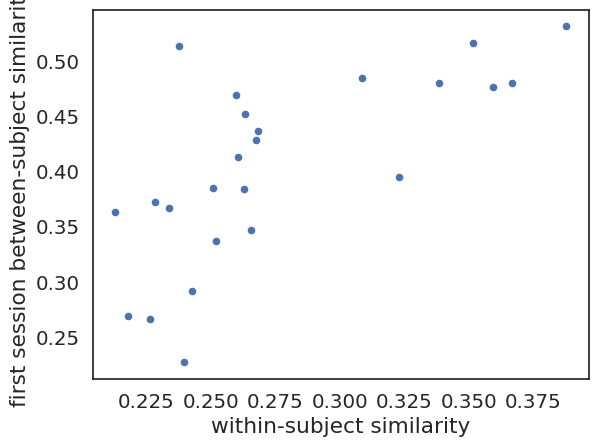

In [29]:
ISC_combined_V1_2.plot.scatter(x = ISC_combined_V1_2.columns[0], y = ISC_combined_V1_2.columns[1])

<Axes: xlabel='within-subject similarity', ylabel='first session between-subject similarity'>

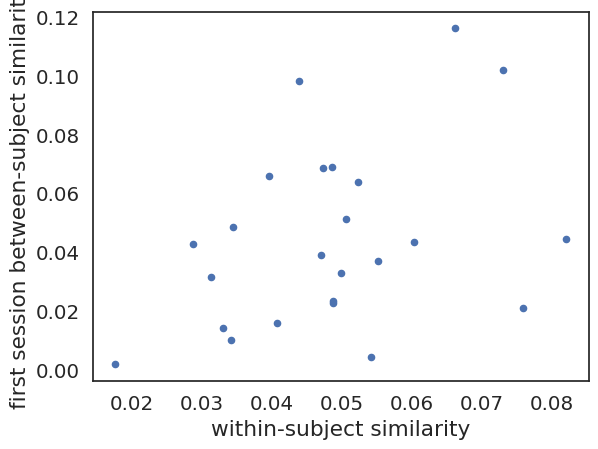

In [33]:
ISC_combined_Vmpfc_2.plot.scatter(x = ISC_combined_Vmpfc_2.columns[0], y = ISC_combined_Vmpfc_2.columns[1])

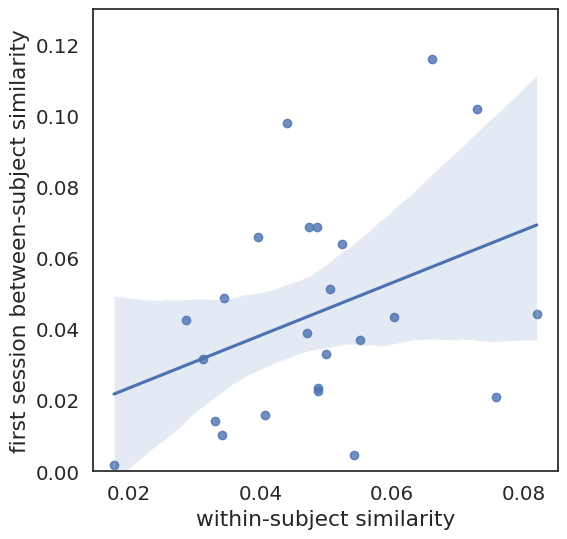

In [46]:
# tips = sns.load_dataset("tips")
sns.set(font_scale=1.3)
sns.set_style('white')
plt.figure(figsize=(6,6))
plt.ylim(0,0.13)
sns.regplot(x=ISC_combined_Vmpfc_2.columns[0], y=ISC_combined_Vmpfc_2.columns[1], data=ISC_combined_Vmpfc_2)


plt.savefig(os.path.join(current_directory,svg_file,"vmPFC_1stbetween_within_comparison.svg"), format="svg")

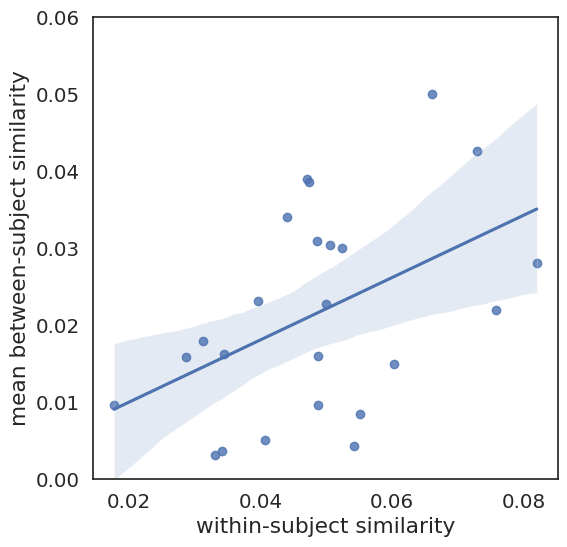

In [49]:
# tips = sns.load_dataset("tips")
sns.set(font_scale=1.3)
sns.set_style('white')
plt.figure(figsize=(6,6))
plt.ylim(0,0.06)
sns.regplot(x=ISC_combined_Vmpfc_2.columns[0], y=ISC_combined_Vmpfc_2.columns[2], data=ISC_combined_Vmpfc_2)


plt.savefig(os.path.join(current_directory,svg_file,"vmPFC_allbetween_within_comparison.svg"), format="svg")

In [60]:
ISC_combined_Vmpfc_2.corr()

,within-subject similarity,first session between-subject similarity,mean between-subject similarity
within-subject similarity,1.000000,0.371875,0.464902
first session between-subject similarity,0.371875,1.000000,0.854243
mean between-subject similarity,0.464902,0.854243,1.000000


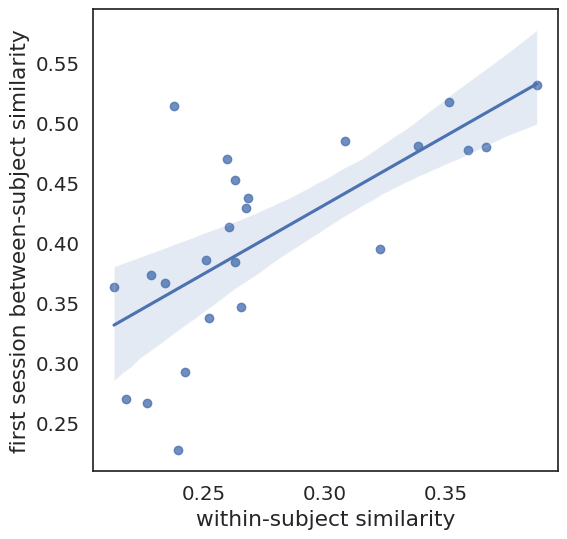

In [58]:
# tips = sns.load_dataset("tips")
sns.set(font_scale=1.3)
sns.set_style('white')
plt.figure(figsize=(6,6))
# plt.ylim(0,0.5)
sns.regplot(x=ISC_combined_V1_2.columns[0], y=ISC_combined_V1_2.columns[1], data=ISC_combined_V1_2)


plt.savefig(os.path.join(current_directory,svg_file,"V1_1stbetween_within_comparison.svg"), format="svg")

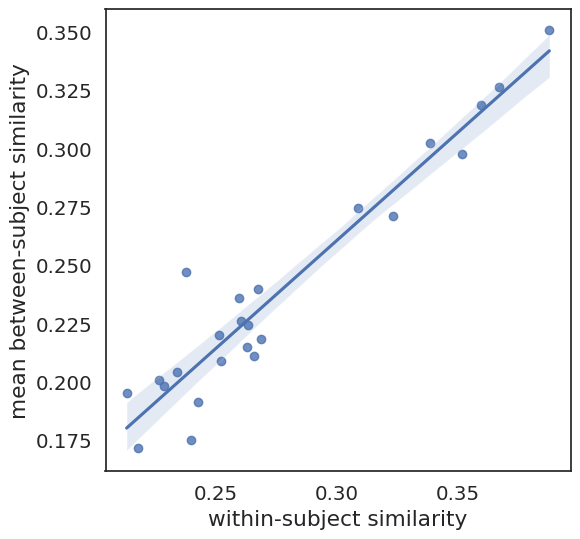

In [59]:
# tips = sns.load_dataset("tips")
sns.set(font_scale=1.3)
sns.set_style('white')
plt.figure(figsize=(6,6))
# plt.ylim(0,0.5)
sns.regplot(x=ISC_combined_V1_2.columns[0], y=ISC_combined_V1_2.columns[2], data=ISC_combined_V1_2)


plt.savefig(os.path.join(current_directory,svg_file,"V1_allbetween_within_comparison.svg"), format="svg")

In [61]:
ISC_combined_V1_2.corr()

,within-subject similarity,first session between-subject similarity,mean between-subject similarity
within-subject similarity,1.000000,0.693510,0.955601
first session between-subject similarity,0.693510,1.000000,0.819522
mean between-subject similarity,0.955601,0.819522,1.000000


### Entire brain maps

### within subject whole brain ISC 

  0%|          | 0/50 [00:00<?, ?it/s]

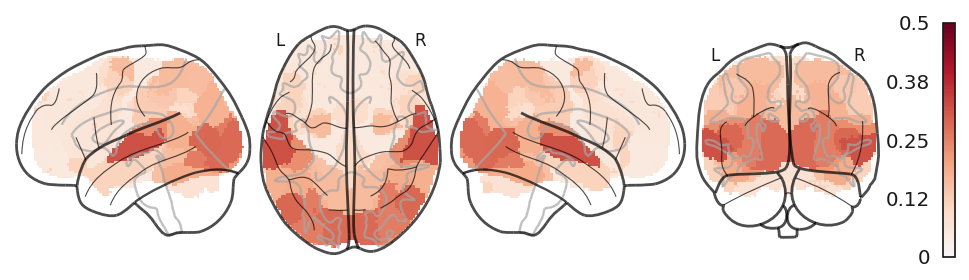

In [63]:
roi_all = mask_x.data.shape[0]
within_ISC_all = []


for roi_num in tqdm(range(roi_all)):

    ISC_within = calculate_within_ISC(subj_sids_iteration,5,roi_num)
    ISC_within = np.arctanh(ISC_within)
#     ISC_combined = pd.concat([ISC_between,ISC_within],axis = 1,join='inner')
#     ISC_combined = np.arctanh(ISC_combined) ## fisher r-2-z
    within_ISC_all.append(ISC_within.mean(axis = 0))
    
within_ISC_all_brain = roi_to_brain(within_ISC_all, mask_x)
plot_glass_brain(within_ISC_all_brain.to_nifti(), display_mode='lzry',colorbar=True,cmap='RdBu_r',vmin=0, vmax=0.5,plot_abs=False)

plt.savefig(os.path.join(current_directory,svg_file,"within_all_ROIs.svg"), format="svg")

### between-subject whole brain ISC 

  0%|          | 0/50 [00:00<?, ?it/s]

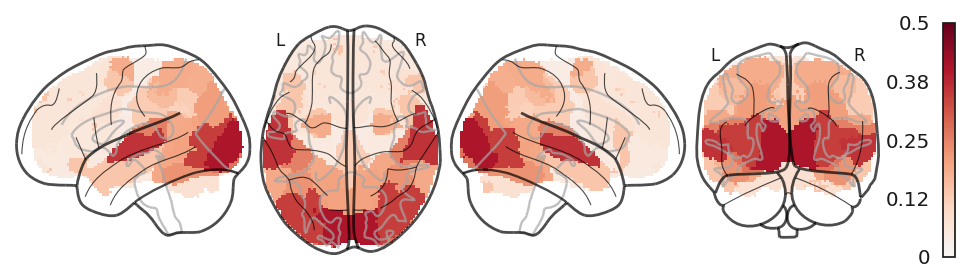

In [64]:
roi_all = mask_x.data.shape[0]
between_ISC_all = []


for roi_num in tqdm(range(roi_all)):
    ISC_between = calculate_between_ISC(subj_sids_iteration,1,roi_num)
    ISC_between = np.arctanh(ISC_between)
    between_ISC_all.append(ISC_between.mean(axis = 0))

between_ISC_all_brain = roi_to_brain(between_ISC_all, mask_x)
plot_glass_brain(between_ISC_all_brain.to_nifti(), display_mode='lzry',colorbar=True,vmin=0, vmax=0.5,cmap='RdBu_r',plot_abs=False)
plt.savefig(os.path.join(current_directory,svg_file,"between1_all_ROIs.svg"), format="svg")

## 5 sessions between_ISC

  0%|          | 0/50 [00:00<?, ?it/s]

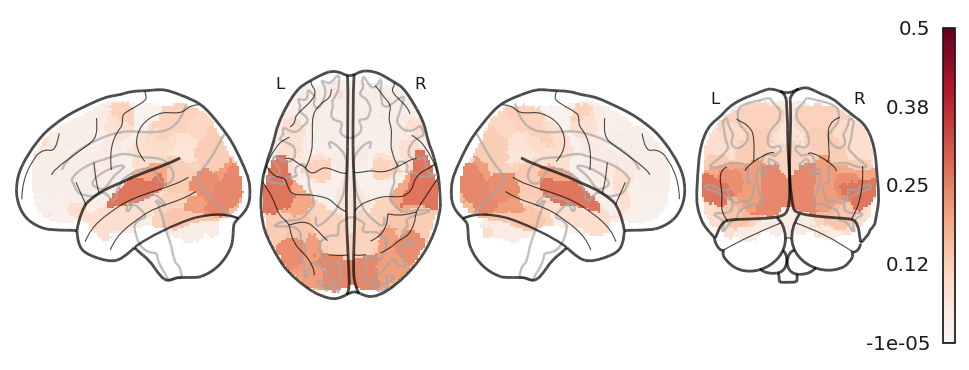

In [149]:
roi_all = mask_x.data.shape[0]
between_ISC_all_5seeions = []

ses_all = ['1','2','3','4','5']



for roi_num in tqdm(range(roi_all)):
    ISC_all_regions_corr = pd.DataFrame([])
    ISC_between = pd.DataFrame([])
    for session_time in ses_all:
        ISC_between = calculate_between_ISC(subj_sids_iteration,session_time,roi_num)
        ISC_between = np.arctanh(ISC_between)
        ISC_between['session_time'] = session_time
#         print(ISC_between.shape)
        
        ISC_all_regions_corr = pd.concat([ISC_all_regions_corr,ISC_between])
#         print(ISC_all_regions_corr.shape,session_time)
        
    ISC_all_corr_mean = ISC_all_regions_corr.pivot(columns='session_time',values = 'between-subject similarity').mean(axis = 1)
    between_ISC_all_5seeions.append(ISC_all_corr_mean.mean(axis = 0))

between_ISC_all_brain_5seeions = roi_to_brain(between_ISC_all_5seeions, mask_x)
plot_glass_brain(between_ISC_all_brain_5seeions.to_nifti(), display_mode='lzry',colorbar=True,cmap=custom_cmap,vmin=0, vmax=0.5,plot_abs=True)
plt.savefig(os.path.join(current_directory,svg_file,"between5_all_ROIs.svg"), format="svg")

In [79]:
## colorbar???

### Entire brain corrs and differences

In [118]:
roi_all = mask_x.data.shape[0]
within_ISC_all = []
between_ISC_all = []
between_ISC_all_5seeions = []
ses_all = ['1','2','3','4','5']

r_between1_within = []
r_between5_within = []

d_between1_within = []
d_between5_within = []


for roi_num in tqdm(range(roi_all)):

    ISC_within = calculate_within_ISC(subj_sids_iteration,5,roi_num)
    ISC_within = np.arctanh(ISC_within)

    ISC_between = calculate_between_ISC(subj_sids_iteration,1,roi_num)
    ISC_between = np.arctanh(ISC_between)

    ISC_all_regions_corr = pd.DataFrame([])
    ISC_between_all = pd.DataFrame([])
    for session_time in ses_all:
        ISC_between_all = calculate_between_ISC(subj_sids_iteration,session_time,roi_num)
        ISC_between_all = np.arctanh(ISC_between_all)
        ISC_between_all['session_time'] = session_time
#         print(ISC_between_all.shape)
        
        ISC_all_regions_corr = pd.concat([ISC_all_regions_corr,ISC_between_all])
#         print(ISC_all_regions_corr.shape,session_time)
        
    ISC_all_corr_mean = ISC_all_regions_corr.pivot(columns='session_time',values = 'between-subject similarity').mean(axis = 1)

    # print(ISC_within.shape)
    # print(ISC_between.shape)
    # print(ISC_all_corr_mean.shape)

    d_between1_within_values = ISC_between['between-subject similarity']-ISC_within
    d_between1_within.append(d_between1_within_values.values.mean())

    d_between5_within_values = ISC_all_corr_mean-ISC_within
    d_between5_within.append(d_between5_within_values.values.mean())
    
    r_between1_within.append(pd.concat([ISC_between['between-subject similarity'],ISC_within], axis = 1).corr().iloc[0,1])
    r_between5_within.append(pd.concat([ISC_all_corr_mean,ISC_within], axis = 1).corr().iloc[0,1])

  0%|          | 0/50 [00:00<?, ?it/s]

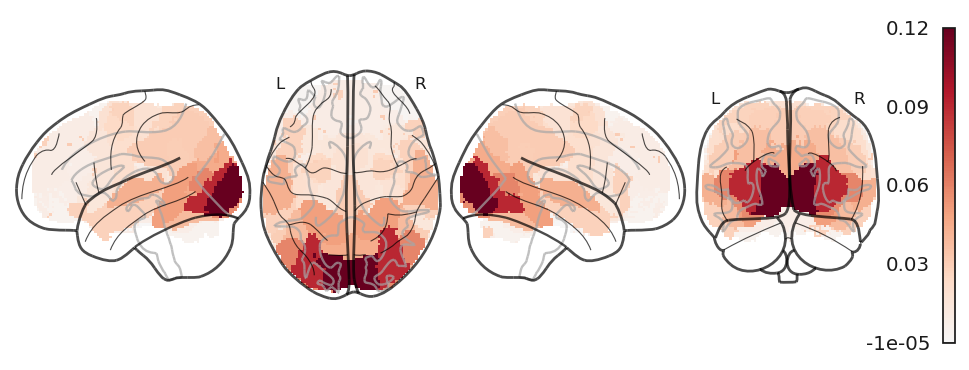

In [148]:
# Get the positive half of the RdBu_r colormap
cmap = plt.get_cmap("RdBu_r")
positive_half = cmap(np.linspace(0.5, 1, 256)) 
custom_cmap = plt.matplotlib.colors.ListedColormap(positive_half)

d_between1_within_brain = roi_to_brain(d_between1_within, mask_x)
plot_glass_brain(d_between1_within_brain.to_nifti(), display_mode='lzry',colorbar=True,cmap=custom_cmap,plot_abs=True)
plt.savefig(os.path.join(current_directory,svg_file,"d_between1_within_brain.svg"), format="svg")

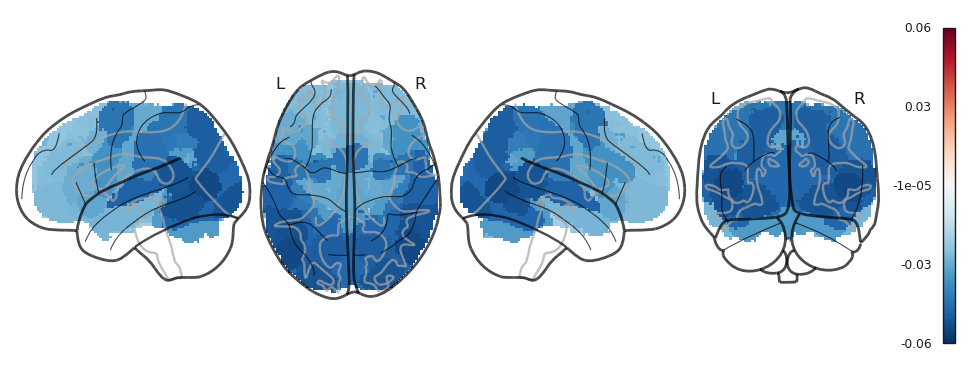

In [147]:
with sns.plotting_context(context='paper', font_scale=1): 
    d_between5_within_brain = roi_to_brain(d_between5_within, mask_x)
    plot_glass_brain(d_between5_within_brain.to_nifti(), display_mode='lzry',cmap='RdBu_r', colorbar=True,plot_abs=False, vmin = -0.06, symmetric_cbar=True)
    plt.savefig(os.path.join(current_directory,svg_file,"d_between5_within_brain.svg"), format="svg")



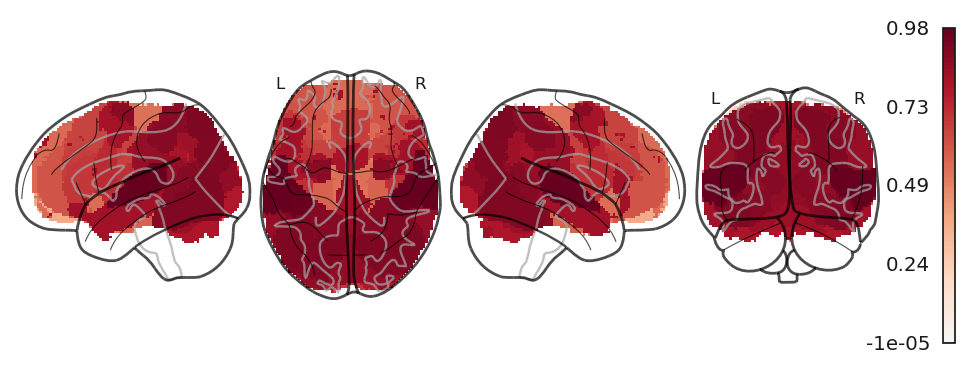

In [128]:
r_between1_within_brain = roi_to_brain(r_between1_within, mask_x)
plot_glass_brain(r_between1_within_brain.to_nifti(), display_mode='lzry',colorbar=True,cmap=custom_cmap,plot_abs=True)
plt.savefig(os.path.join(current_directory,svg_file,"r_between1_within.svg"), format="svg")

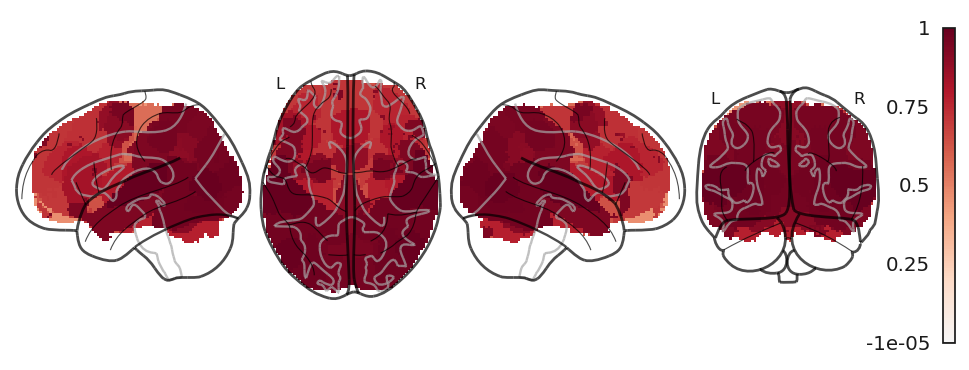

In [129]:
r_between5_within_brain = roi_to_brain(r_between5_within, mask_x)
plot_glass_brain(r_between5_within_brain.to_nifti(), display_mode='lzry',colorbar=True,cmap=custom_cmap,plot_abs=True)
plt.savefig(os.path.join(current_directory,svg_file,"r_between5_within.svg"), format="svg")

## For each video, corrs based on Entire brain patterns (50 ROIs)

In [8]:
import pandas as pd
import glob
import time
from tqdm.notebook import tqdm
import numpy as np
import xarray as xr
from joblib import Parallel, delayed

roi_all = mask_x.data.shape[0]
within_ISC_all = []
between_ISC_all = []
between_ISC_all_5seeions = []
ses_all = ['1','2','3','4','5']

ISC_videos_ROIs = pd.DataFrame()


for roi_num in tqdm(range(roi_all)):

    ISC_within = calculate_within_ISC(subj_sids_iteration,5,roi_num)
    ISC_within = np.arctanh(ISC_within)

    ISC_between = calculate_between_ISC(subj_sids_iteration,1,roi_num)
    ISC_between = np.arctanh(ISC_between)

    ISC_all_regions_corr = pd.DataFrame([])
    ISC_between_all = pd.DataFrame([])
    for session_time in ses_all:
        ISC_between_all = calculate_between_ISC(subj_sids_iteration,session_time,roi_num)
        ISC_between_all = np.arctanh(ISC_between_all)
        ISC_between_all['session_time'] = session_time
#         print(ISC_between_all.shape)
        
        ISC_all_regions_corr = pd.concat([ISC_all_regions_corr,ISC_between_all])
#         print(ISC_all_regions_corr.shape,session_time)
        
    ISC_all_corr_mean = ISC_all_regions_corr.pivot(columns='session_time',values = 'between-subject similarity').mean(axis = 1)

    ISC_between['within-subject similarity'] = ISC_within
    ISC_between['between-subject5 similarity'] = ISC_all_corr_mean
    ISC_between['ROI'] = roi_num

    ISC_videos_ROIs = pd.concat([ISC_videos_ROIs,ISC_between], axis = 0)



  0%|          | 0/50 [00:00<?, ?it/s]

In [9]:
ISC_videos_ROIs

,between-subject similarity,within-subject similarity,between-subject5 similarity,ROI
movie_name,,,,
Nature,-0.005877,0.015720,-0.004959,0
Asian cake,0.008550,0.043705,0.022083,0
Ribbon climbing,0.025734,0.064170,0.006645,0
Kiss me,0.029108,0.027985,0.006099,0
Syrian,0.035591,0.064619,0.034808,0
...,...,...,...,...
Lapse,0.175745,0.117005,0.109363,49
Newsroom,0.209587,0.168571,0.132569,49
Russian,0.201440,0.165755,0.123268,49


In [10]:
ISC_videos_ROIs_between_within = []
ISC_videos_ROIs_between5_within = []
for i in ISC_videos_ROIs.index.unique():
    ISC_videos_ROIs_values = ISC_videos_ROIs[ISC_videos_ROIs.index == i].sort_values(by='ROI')
    ISC_videos_ROIs_between_within.append(ISC_videos_ROIs_values.corr().iloc[1,0])
    ISC_videos_ROIs_between5_within.append(ISC_videos_ROIs_values.corr().iloc[1,2])

In [12]:
import statistics
statistics.mean(ISC_videos_ROIs_between_within)

0.9657482445354749

In [13]:
statistics.stdev(ISC_videos_ROIs_between_within)

0.010382307718160478

(0.94, 0.98)

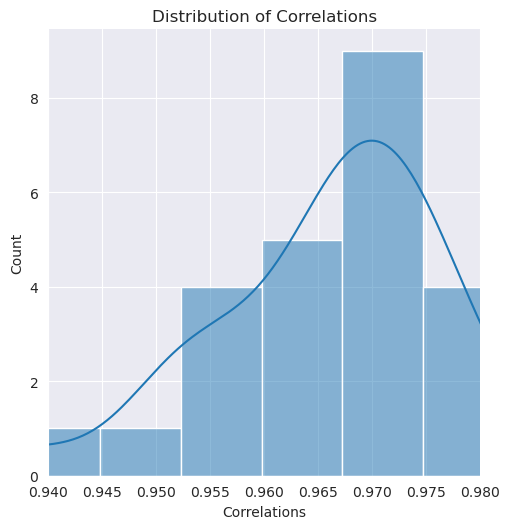

In [40]:
import seaborn as sns
import pandas as pd
import matplotlib # if abbreviating this, use "as mpl"
import matplotlib.pyplot as plt

sns.set_style('darkgrid')
sns.displot(ISC_videos_ROIs_between_within,kde=True)  # Frequency barplot

plt.xlabel('Correlations')
plt.ylabel('Count')
plt.title('Distribution of Correlations')

# Set x-axis range
plt.xlim(0.94, 0.98)  # Adjust the range as needed
# plt.savefig(os.path.join(current_directory,svg_file,"Distribution_correlations_between_within.svg"), format="svg")

In [44]:
ttest_1samp(ISC_videos_ROIs_between_within, 0)

TtestResult(statistic=455.6964565715335, pvalue=5.322996112110614e-47, df=23)

In [ ]:
sns.set(font_scale=1.3)
sns.set_style('white')
plt.figure(figsize=(6,6))
# plt.ylim(0,0.5)
sns.regplot(x=ISC_combined_V1_2.columns[0], y=ISC_combined_V1_2.columns[1], data=ISC_combined_V1_2)


plt.savefig(os.path.join(current_directory,svg_file,"V1_1stbetween_within_comparison.svg"), format="svg")

In [41]:
ISC_videos_ROIs[ISC_videos_ROIs.index == i].sort_values(by='ROI').corr()

,between-subject similarity,within-subject similarity,between-subject5 similarity,ROI
between-subject similarity,1.000000,0.974111,0.981022,0.058253
within-subject similarity,0.974111,1.000000,0.995091,0.104968
between-subject5 similarity,0.981022,0.995091,1.000000,0.090583
ROI,0.058253,0.104968,0.090583,1.000000


In [43]:
ISC_videos_ROIs

,between-subject similarity,within-subject similarity,between-subject5 similarity,ROI
movie_name,,,,
Nature,-0.005877,0.015720,-0.004959,0
Asian cake,0.008550,0.043705,0.022083,0
Ribbon climbing,0.025734,0.064170,0.006645,0
Kiss me,0.029108,0.027985,0.006099,0
Syrian,0.035591,0.064619,0.034808,0
...,...,...,...,...
Lapse,0.175745,0.117005,0.109363,49
Newsroom,0.209587,0.168571,0.132569,49
Russian,0.201440,0.165755,0.123268,49


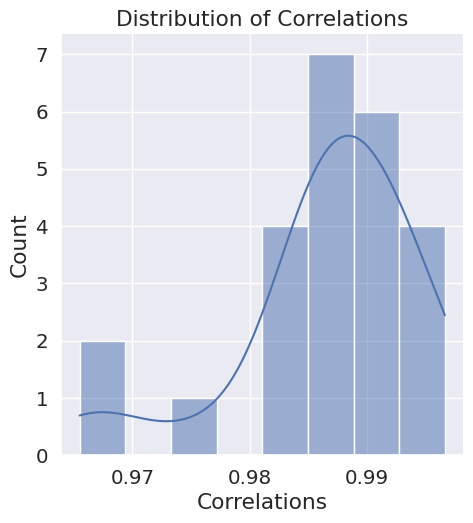

In [188]:
sns.set_style('darkgrid')
sns.displot(ISC_videos_ROIs_between5_within,kde=True)  # Frequency barplot

plt.xlabel('Correlations')
plt.ylabel('Count')
plt.title('Distribution of Correlations')

plt.savefig(os.path.join(current_directory,svg_file,"Distribution_correlations_between5_within.svg"), format="svg")


In [49]:
ISC_videos_ROIs_dots = []
for i in ISC_videos_ROIs.index.unique():
    ISC_videos_ROIs_dots.append([ISC_videos_ROIs[ISC_videos_ROIs.index == i].sort_values(by='ROI')['between-subject similarity'].mean(), ISC_videos_ROIs[ISC_videos_ROIs.index == i].sort_values(by='ROI')['within-subject similarity'].mean()])

In [55]:
ISC_videos_ROIs_dots_pd = pd.DataFrame(ISC_videos_ROIs_dots, columns = ['between-subject similarity', 'within-subject similarity'])

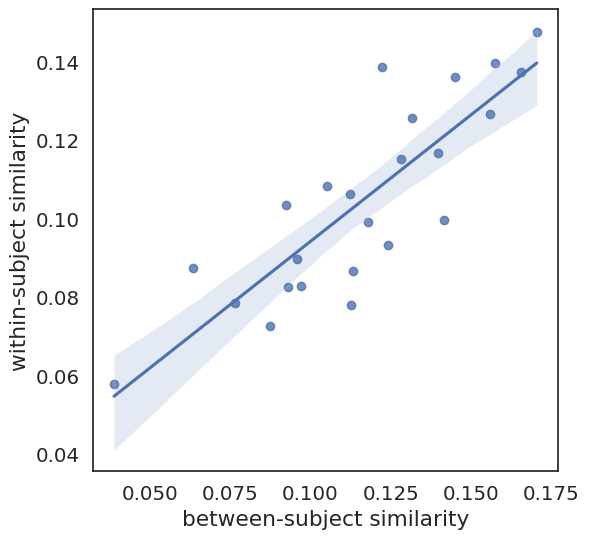

In [61]:
# tips = sns.load_dataset("tips")
sns.set(font_scale=1.3)
sns.set_style('white')
plt.figure(figsize=(6,6))
# plt.ylim(0,0.2)
# plt.xlim(0,0.2)
sns.regplot(x=ISC_videos_ROIs_dots_pd['between-subject similarity'], y=ISC_videos_ROIs_dots_pd['within-subject similarity'], data=ISC_videos_ROIs_dots_pd)


plt.savefig(os.path.join(current_directory,svg_file,"correlations_between5_within_comparison_corr.svg"), format="svg")

## Statistical analysis

In [23]:
ISC_all_corr_V1_model = ISC_all_corr_V1.pivot(columns='session time',values = 'between-subject similarity')
ISC_all_corr_Vmpfc_model = ISC_all_corr_Vmpfc.pivot(columns='session time',values = 'between-subject similarity')

In [137]:
linear_contrast = np.array([-2,-1,0,1,2])

sim1_linear_V1 = np.dot(ISC_all_corr_V1_model, linear_contrast)
sim1_linear_Vmpfc = np.dot(ISC_all_corr_Vmpfc_model, linear_contrast)

In [138]:
from scipy.stats import ttest_1samp

t_statistic_V1, p_value_V1 = ttest_1samp(sim1_linear_V1, 0)
t_statistic_vmPFC, p_value_vmPFC = ttest_1samp(sim1_linear_Vmpfc, 0)
print(t_statistic_V1,p_value_V1,t_statistic_vmPFC,p_value_vmPFC)

-19.001970402634413 1.4714766612808287e-15 -6.430416414412121 1.4612400345938174e-06


In [155]:
print(ttest_1samp(sim1_linear_V1, 0),ttest_1samp(sim1_linear_Vmpfc, 0))

TtestResult(statistic=-19.001970402634413, pvalue=1.4714766612808287e-15, df=23) TtestResult(statistic=-6.430416414412121, pvalue=1.4612400345938174e-06, df=23)


In [140]:
print(sim1_linear_V1.mean(),sim1_linear_Vmpfc.mean())

-0.712171934516966 -0.09665761613976538


#### Differences between conditions

In [26]:
# within-averaged between
from scipy.stats import ttest_1samp

In [24]:
ISC_vmpfc_com1 = pd.DataFrame(ISC_combined_Vmpfc_2['within-subject similarity']-ISC_combined_Vmpfc_2['mean between-subject similarity'])

In [27]:
ttest_1samp(ISC_vmpfc_com1, 0)

TtestResult(statistic=array([8.80888996]), pvalue=array([7.90452688e-09]), df=array([23]))

In [149]:
ISC_vmpfc_com2 = pd.DataFrame(ISC_combined_Vmpfc_2['within-subject similarity']-ISC_combined_Vmpfc_2['first session between-subject similarity'])
ttest_1samp(ISC_vmpfc_com2, 0)


TtestResult(statistic=array([0.68072097]), pvalue=array([0.50284408]), df=array([23]))

In [152]:
ISC_V1_com1 = pd.DataFrame(ISC_combined_V1_2['V1 within-subject similarity']-ISC_combined_V1_2['V1 mean between-subject similarity'])

ttest_1samp(ISC_V1_com1, 0)

TtestResult(statistic=array([12.15270004]), pvalue=array([1.71652536e-11]), df=array([23]))

In [154]:
ISC_V1_com2 = pd.DataFrame(ISC_combined_V1_2['V1 within-subject similarity']-ISC_combined_V1_2['V1 first session between-subject similarity'])

ttest_1samp(ISC_V1_com2, 0)

TtestResult(statistic=array([-10.11963537]), pvalue=array([6.10516413e-10]), df=array([23]))

In [24]:
from scipy.stats import ttest_1samp
ISC_vmpfc_com3 = pd.DataFrame(ISC_combined_Vmpfc_2['mean between-subject similarity']-ISC_combined_Vmpfc_2['first session between-subject similarity'])
ttest_1samp(ISC_vmpfc_com3, 0)


TtestResult(statistic=array([-5.50948946]), pvalue=array([1.33009814e-05]), df=array([23]))

In [34]:
ISC_V1_com3 = pd.DataFrame(ISC_combined_V1_2['mean between-subject ISC']-ISC_combined_V1_2['V1 between-subject ISC'])
ttest_1samp(ISC_V1_com3, 0)

TtestResult(statistic=array([-15.35372984]), pvalue=array([1.40245485e-13]), df=array([23]))